# Reasoning length vs. accuracy — how early can we stop generation?

**Motivation.** Evaluating the distillation trainings is now the bottleneck (not training).
Each MMLU eval generates up to **8192 thinking tokens** (`max_thinking_tokens=8192`,
`max_new_tokens=8500`) per question, over ~2406 questions × ~63 checkpoints. Hypothesis:
*most long reasoning chains are garbage*, so correct answers come from short chains and we
could stop generation far earlier to speed up evals.

This notebook verifies that empirically. For each `(model, truncation_type,
truncation_value)` variant it measures how reasoning-chain length relates to correctness,
in **chars and tokens**, **absolute and relative** (relative = % of the 8192-token thinking
budget), and produces the **retained-accuracy-vs-cap** curve that directly answers *how
early can we stop and what accuracy do we keep*.

**Data.** `artifacts/distillation_on_synthetic_traces/mmlu/direct_reasoning_trace/<variant>/checkpoint-N/evals/mmlu_random_test/responses.parquet`.
The stored `response` has the form `"{reasoning}</think>{answer}<|eot_id|>"` (no opening
`<think>`), so the **reasoning chain = everything before `</think>`**. Token counts are
produced with each model's own tokenizer; tokenizing the reasoning substring faithfully
reproduces the generator's thinking-token count (budget-exhausted chains → ~8191 tokens).

> **Headline tables** are computed on the **best-accuracy** and **final** checkpoint per
> variant; a dedicated section analyses **length dynamics across all epochs**.

## 1. Setup

In [ ]:
import os

os.environ.setdefault("HF_HUB_OFFLINE", "1")  # tokenizers are cached locally
os.environ.setdefault("TRANSFORMERS_OFFLINE", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "1")

import json
import re
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer

# make `core` importable even if the notebook is run with a bare kernel
for up in Path.cwd().resolve().parents:
    if (up / "src" / "core").is_dir():
        sys.path.insert(0, str(up / "src"))
        break
try:
    from core.utils.graph_style import set_style

    set_style()
except Exception:  # pragma: no cover - styling is non-essential
    sns.set_theme(palette="deep", style="whitegrid")
# poster context is too large for multi-panel grids; use a practical default
sns.set_context("talk")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

## 2. Configuration

In [ ]:
def find_repo_root(start: Path | None = None) -> Path:
    # walk up until a dir containing both artifacts/ and src/ is found
    start = (start or Path.cwd()).resolve()
    for d in [start, *start.parents]:
        if (d / "artifacts").is_dir() and (d / "src").is_dir():
            return d
    raise FileNotFoundError("repo root (with artifacts/ and src/) not found above cwd")


ROOT = find_repo_root()
TRACE_DIR = ROOT / "artifacts/distillation_on_synthetic_traces/mmlu/direct_reasoning_trace"
BASE_MODELS = Path("/Users/aigoncharov/base_models_v0")  # local tokenizers (training source)
HF_IDS = {  # fallback if local dir is absent
    "llama_3b": "meta-llama/Llama-3.2-3B-Instruct",
    "qwen_3b": "Qwen/Qwen2.5-3B-Instruct",
    "phi4_mini": "microsoft/Phi-4-mini-instruct",
}
EVAL_DATASET_ID = "mmlu_random_test"
THINK_END = "</think>"
THINKING_BUDGET = 8192  # max_thinking_tokens during eval
CAP_FOCUS = 4096  # cap analysed in detail below
MODEL_ORDER = ["llama_3b", "qwen_3b", "phi4_mini"]
DIR_RE = re.compile(r"^(?P<model>llama_3b|qwen_3b|phi4_mini)_(?P<ttype>head|middle|tail)_truncated(?P<tval>\d+)$")

CACHE_PATH = ROOT / "artifacts/reasoning_length_vs_accuracy/lengths.parquet"
OUT_DIR = ROOT / "artifacts/reasoning_length_vs_accuracy"
OUT_DIR.mkdir(parents=True, exist_ok=True)
REBUILD_CACHE = False  # set True to re-tokenize from scratch
print("repo root:", ROOT)

repo root: /Users/aigoncharov/dev/sktech/recursive_caft


## 3–4. Load responses & count reasoning tokens (cached)

We load every checkpoint's `responses.parquet`, parse `(model, truncation_type,
truncation_value)` from the variant directory name, attach the `checkpoint → (epoch,
accuracy)` mapping from each variant's `summary_reasoning_evals.json`, split out the
reasoning chain, and count its tokens with the model's own tokenizer. Token counts are
cached to `data/out/reasoning_length_vs_accuracy/lengths.parquet` (≈3 min to build, instant
to reload).

In [ ]:
def load_all_responses() -> pd.DataFrame:
    frames = []
    for variant_dir in sorted(TRACE_DIR.iterdir()):
        if not variant_dir.is_dir():
            continue
        m = DIR_RE.match(variant_dir.name)
        if not m:
            print("  skip (unparseable):", variant_dir.name)
            continue
        model, ttype, tval = m["model"], m["ttype"], int(m["tval"])

        ep_map, acc_map = {}, {}
        summ = variant_dir / "summary_reasoning_evals.json"
        if summ.exists():
            for rec in json.loads(summ.read_text()).get(EVAL_DATASET_ID, []):
                ep_map[rec["checkpoint"]] = rec["epoch"]
                acc_map[rec["checkpoint"]] = rec["accuracy"]

        for ckpt_dir in sorted(variant_dir.glob("checkpoint-*")):
            resp = ckpt_dir / "evals" / EVAL_DATASET_ID / "responses.parquet"
            if not resp.exists():
                continue
            d = pd.read_parquet(resp)
            d["model"] = model
            d["truncation_type"] = ttype
            d["truncation_value"] = tval
            d["variant"] = variant_dir.name
            d["checkpoint"] = ckpt_dir.name
            d["epoch"] = ep_map.get(ckpt_dir.name, np.nan)
            d["variant_accuracy"] = acc_map.get(ckpt_dir.name, np.nan)
            frames.append(d)

    out = pd.concat(frames, ignore_index=True)
    out["has_think"] = out["response"].str.contains(THINK_END, regex=False)
    out["reasoning"] = out["response"].str.split(THINK_END, n=1).str[0]
    out["reason_chars"] = out["reasoning"].str.len().astype("int64")
    return out


def load_tokenizer(model: str):
    for src in [str(BASE_MODELS / model), HF_IDS[model]]:
        try:
            return AutoTokenizer.from_pretrained(src, trust_remote_code=True)
        except Exception as e:  # noqa: BLE001
            print(f"  tokenizer load failed for {src}: {repr(e)[:90]}")
    raise RuntimeError(f"could not load tokenizer for {model}")


def add_token_counts(df: pd.DataFrame) -> pd.DataFrame:
    # No <think>/</think> special tokens needed: the reasoning substring is plain text and
    # add_special_tokens=False reproduces the generator's thinking-token count.
    df = df.copy()
    df["reason_tokens"] = -1
    for model, sub in df.groupby("model"):
        t0 = time.time()
        tok = load_tokenizer(model)
        lens = []
        texts = sub["reasoning"].tolist()
        for i in range(0, len(texts), 2000):
            lens.extend(len(x) for x in tok(texts[i : i + 2000], add_special_tokens=False)["input_ids"])
        df.loc[sub.index, "reason_tokens"] = lens
        print(f"  tokenized {model}: {len(sub):>7,} rows in {time.time() - t0:4.0f}s")
    df["reason_tokens"] = df["reason_tokens"].astype("int64")
    return df


CACHE_COLS = [
    "row_id",
    "model",
    "truncation_type",
    "truncation_value",
    "variant",
    "checkpoint",
    "epoch",
    "variant_accuracy",
    "is_correct",
    "is_truncated",
    "is_thinking_budget_exhausted",
    "has_think",
    "reason_chars",
    "reason_tokens",
]
if CACHE_PATH.exists() and not REBUILD_CACHE:
    df = pd.read_parquet(CACHE_PATH)
    print(f"loaded cache: {len(df):,} rows")
else:
    print("building cache (load + tokenize)…")
    df = add_token_counts(load_all_responses())
    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    df[CACHE_COLS].to_parquet(CACHE_PATH, index=False)
    print(f"cached -> {CACHE_PATH}")
print(
    f"{len(df):,} rows · {df['variant'].nunique()} variants · "
    f"{df.groupby('variant')['checkpoint'].nunique().sum()} checkpoints"
)

loaded cache: 151,578 rows
151,578 rows · 9 variants · 63 checkpoints


### Sanity checks & derived columns

In [ ]:
# faithfulness: budget-exhausted chains should tokenize to ~8191 (the 8192 budget)
be_med = int(df.loc[df["is_thinking_budget_exhausted"], "reason_tokens"].median())
assert 8180 <= be_med <= 8200, f"budget-exhausted token sanity failed: {be_med}"
# accuracy spot-check vs a known summary value
spot = df[(df.variant == "llama_3b_head_truncated8192") & (df.checkpoint == "checkpoint-151")]
print(f"sanity: budget-exhausted median tokens = {be_med} (≈8191)")
print(f"spot accuracy llama_3b_head_truncated8192/checkpoint-151 = {spot['is_correct'].mean():.4f} (expect 0.4069)")

# per-model chars/token → char-equivalent of the 8192-token budget (for relative chars)
cpt = (df["reason_chars"] / df["reason_tokens"].clip(lower=1)).groupby(df["model"]).median()
char_budget_map = (cpt * THINKING_BUDGET).to_dict()
df["char_budget"] = df["model"].map(char_budget_map)
df["rel_token"] = df["reason_tokens"] / THINKING_BUDGET  # fraction of 8192-token budget
df["rel_char"] = df["reason_chars"] / df["char_budget"]  # fraction of char-budget
df["ckpt_step"] = df["checkpoint"].str.split("-").str[1].astype(int)
print("\nchars/token (median) & char-budget per model:")
for m in MODEL_ORDER:
    print(f"  {m:10s} cpt={cpt[m]:5.2f}  char_budget={int(char_budget_map[m]):,}")

sanity: budget-exhausted median tokens = 8191 (≈8191)
spot accuracy llama_3b_head_truncated8192/checkpoint-151 = 0.4069 (expect 0.4069)

chars/token (median) & char-budget per model:
  llama_3b   cpt= 4.06  char_budget=33,265
  qwen_3b    cpt= 3.98  char_budget=32,591
  phi4_mini  cpt= 4.10  char_budget=33,576


## 5. Select the *best* and *final* checkpoint per variant

`best` = highest accuracy (computed directly from the data, which is always present),
`final` = largest checkpoint step. Headline tables stack both with a `role` column; a
checkpoint that is both simply shows identical numbers under each role.

In [5]:
rows = []
for variant, sub in df.groupby("variant"):
    by_ck = sub.groupby("checkpoint").agg(acc=("is_correct", "mean"), step=("ckpt_step", "first"))
    rows.append((variant, by_ck["acc"].idxmax(), by_ck["step"].idxmax()))
sel = pd.DataFrame(rows, columns=["variant", "best_ckpt", "final_ckpt"])

best_keys = set(zip(sel.variant, sel.best_ckpt))
final_keys = set(zip(sel.variant, sel.final_ckpt))
keys = list(zip(df.variant, df.checkpoint))
final_df = df[[k in final_keys for k in keys]].assign(role="final")
best_df = df[[k in best_keys for k in keys]].assign(role="best")
headline = pd.concat([final_df, best_df], ignore_index=True)
for d in (df, final_df, best_df, headline):
    d["model"] = pd.Categorical(d["model"], MODEL_ORDER, ordered=True)
print(sel.to_string(index=False))
print(f"\nheadline rows: {len(headline):,}  (final {len(final_df):,} + best {len(best_df):,})")

                       variant       best_ckpt      final_ckpt
  llama_3b_head_truncated24000 checkpoint-1510 checkpoint-1510
   llama_3b_head_truncated8192 checkpoint-1510 checkpoint-3020
llama_3b_middle_truncated24000  checkpoint-453  checkpoint-453
  llama_3b_tail_truncated24000  checkpoint-635 checkpoint-2540
  phi4_mini_head_truncated8192 checkpoint-2265 checkpoint-3020
   qwen_3b_head_truncated24000 checkpoint-2265 checkpoint-3020
    qwen_3b_head_truncated8192 checkpoint-1208 checkpoint-3020
 qwen_3b_middle_truncated24000 checkpoint-3020 checkpoint-3020
   qwen_3b_tail_truncated24000 checkpoint-1490 checkpoint-2980

headline rows: 43,308  (final 21,654 + best 21,654)


## 6. Quantile tables at multiple granularities

For each grouping we report length quantiles in **tokens** and **chars**, both **absolute**
and **relative** (relative = % of the 8192-token thinking budget; for chars, % of the
per-model char-budget). Computed for **correct-only** (primary), and also **all** and
**incorrect** for comparison.

- `*_max` on the correct-only table = **the longest reasoning chain that still produced the
  correct answer**.
- `tok_max_excl_be` excludes budget-exhausted chains, which are **right-censored** at ~8192
  (the generator forced them to stop). `n_budget_exhausted` shows how many chains hit the
  ceiling — large values mean the true tail is unknown.
- Relative columns and `accuracy` are shown in **percent**.

Granularity levels: **L0** overall · **L1** by model · **L2** by model×truncation_value ·
**L3** full variant (model×type×value). All levels are saved as CSVs in `OUT_DIR`.

In [ ]:
PCTS = {"p50": 0.5, "p70": 0.70, "p75": 0.75, "p80": 0.80, "p90": 0.90, "p95": 0.95, "p99": 0.99}
COLS = [("reason_tokens", "tok"), ("reason_chars", "char"), ("rel_token", "reltok"), ("rel_char", "relchar")]


def quantile_summary(d: pd.DataFrame, by) -> pd.DataFrame:
    by = [by] if isinstance(by, str) else list(by)
    g = d.groupby(by, dropna=False, observed=True)
    res = pd.DataFrame(
        {
            "n": g.size(),
            "accuracy": g["is_correct"].mean(),
            "n_budget_exhausted": g["is_thinking_budget_exhausted"].sum(),
        }
    )
    for col, pref in COLS:
        res[f"{pref}_mean"] = g[col].mean()
        for name, q in PCTS.items():
            res[f"{pref}_{name}"] = g[col].quantile(q)
        res[f"{pref}_max"] = g[col].max()
    res["tok_max_excl_be"] = (
        d[~d.is_thinking_budget_exhausted].groupby(by, dropna=False, observed=True)["reason_tokens"].max()
    )
    return res.reset_index()


def round_table(t: pd.DataFrame) -> pd.DataFrame:
    t = t.copy()
    for c in t.columns:
        if c.startswith(("tok_", "char_")):
            t[c] = t[c].round(0).astype("Int64")
        elif c.startswith(("reltok_", "relchar_")) or c == "accuracy":
            t[c] = (t[c] * 100).round(1)  # → percent
    return t


LEVELS = {
    "L0_overall": ["role"],
    "L1_model": ["role", "model"],
    "L2_model_tval": ["role", "model", "truncation_value"],
    "L3_variant": ["role", "model", "truncation_type", "truncation_value"],
}


def make_tables(pop_df, label):
    out = {}
    for lvl, by in LEVELS.items():
        t = round_table(quantile_summary(pop_df, by))
        t.to_csv(OUT_DIR / f"quantiles_{label}_{lvl}.csv", index=False)
        out[lvl] = t
    return out


tabs_correct = make_tables(headline[headline.is_correct], "correct")
tabs_all = make_tables(headline, "all")
tabs_incorrect = make_tables(headline[~headline.is_correct], "incorrect")
print("saved", len(LEVELS) * 3, "quantile CSVs to", OUT_DIR.name)

saved 12 quantile CSVs to reasoning_length_vs_accuracy


### Correct-only reasoning length by model (tokens)

In [ ]:
show = [
    "role",
    "model",
    "n",
    "tok_p50",
    "tok_p70",
    "tok_p80",
    "tok_p90",
    "tok_p95",
    "tok_p99",
    "tok_max",
    "tok_max_excl_be",
    "reltok_p95",
    "reltok_p99",
]
tabs_correct["L1_model"][show]

,role,model,n,tok_p50,tok_p70,tok_p80,tok_p90,tok_p95,tok_p99,tok_max,tok_max_excl_be,reltok_p95,reltok_p99
0,best,llama_3b,4335,323,726,1938,8191,8191,8191,8193,8137,100.0,100.0
1,best,qwen_3b,4891,412,1007,2469,8191,8191,8191,8195,8149,100.0,100.0
2,best,phi4_mini,1388,366,744,1289,2183,2869,3401,3780,3780,35.0,41.5
3,final,llama_3b,4291,350,848,1945,5540,8191,8191,8193,8137,100.0,100.0
4,final,qwen_3b,4761,444,1117,2435,7937,8191,8191,8200,7937,100.0,100.0
5,final,phi4_mini,1386,386,828,1629,2495,3027,3521,3822,3822,37.0,43.0


### Correct-only reasoning length by full variant (tokens; final checkpoint)

In [ ]:
show_v = [
    "model",
    "truncation_type",
    "truncation_value",
    "n",
    "n_budget_exhausted",
    "tok_p50",
    "tok_p90",
    "tok_p95",
    "tok_p99",
    "tok_max_excl_be",
    "char_p95",
    "reltok_p95",
]
tabs_correct["L3_variant"].query("role == 'final'")[show_v]

,model,truncation_type,truncation_value,n,n_budget_exhausted,tok_p50,tok_p90,tok_p95,tok_p99,tok_max_excl_be,char_p95,reltok_p95
9,llama_3b,head,8192,1117,16,447,3352,3719,8191,6403,11374,45.4
10,llama_3b,head,24000,1095,181,372,8191,8191,8191,8137,30397,100.0
11,llama_3b,middle,24000,1000,142,264,8191,8191,8191,4746,31500,100.0
12,llama_3b,tail,24000,1079,47,365,3088,7208,8191,8046,17846,88.0
13,qwen_3b,head,8192,1212,21,470,3794,4524,8191,7590,12738,55.2
14,qwen_3b,head,24000,1173,204,455,8191,8191,8191,7794,29142,100.0
15,qwen_3b,middle,24000,1213,191,429,8191,8191,8191,7937,26507,100.0
16,qwen_3b,tail,24000,1163,60,431,3934,8188,8191,7926,16164,99.9
17,phi4_mini,head,8192,1386,0,386,2495,3027,3521,3822,10616,37.0


### Correct vs. incorrect vs. all — median & P95 reasoning length by model (final)

In [ ]:
def mini(tabs, pop):
    t = tabs["L1_model"].query("role == 'final'")[["model", "n", "accuracy", "tok_p50", "tok_p95"]].copy()
    t.insert(1, "population", pop)
    return t


cmp = pd.concat(
    [mini(tabs_all, "all"), mini(tabs_correct, "correct"), mini(tabs_incorrect, "incorrect")], ignore_index=True
)
cmp.sort_values(["model", "population"]).reset_index(drop=True)

,model,population,n,accuracy,tok_p50,tok_p95
0,llama_3b,all,9624,44.6,688,8191
1,llama_3b,correct,4291,100.0,350,8191
2,llama_3b,incorrect,5333,0.0,1460,8191
3,qwen_3b,all,9624,49.5,835,8191
4,qwen_3b,correct,4761,100.0,444,8191
5,qwen_3b,incorrect,4863,0.0,1900,8191
6,phi4_mini,all,2406,57.6,714,3563
7,phi4_mini,correct,1386,100.0,386,3027
8,phi4_mini,incorrect,1020,0.0,2137,3715


## 7. Retained accuracy vs. generation cap  *(headline)*

For a thinking-token cap `T`, **retained accuracy** = fraction of questions that are
currently correct **and** whose reasoning fits in `T` tokens
(`is_correct & reason_tokens ≤ T`). As `T → 8192` it converges to the model's real accuracy.

*Assumption:* the answer is emitted right after `</think>`, so capping thinking at `T` loses
any currently-correct response whose reasoning exceeds `T`. This is a descriptive
upper bound on retained accuracy (a hard cap could also change which answers become correct).
Computed on the **final** checkpoint per variant (one curve per variant).

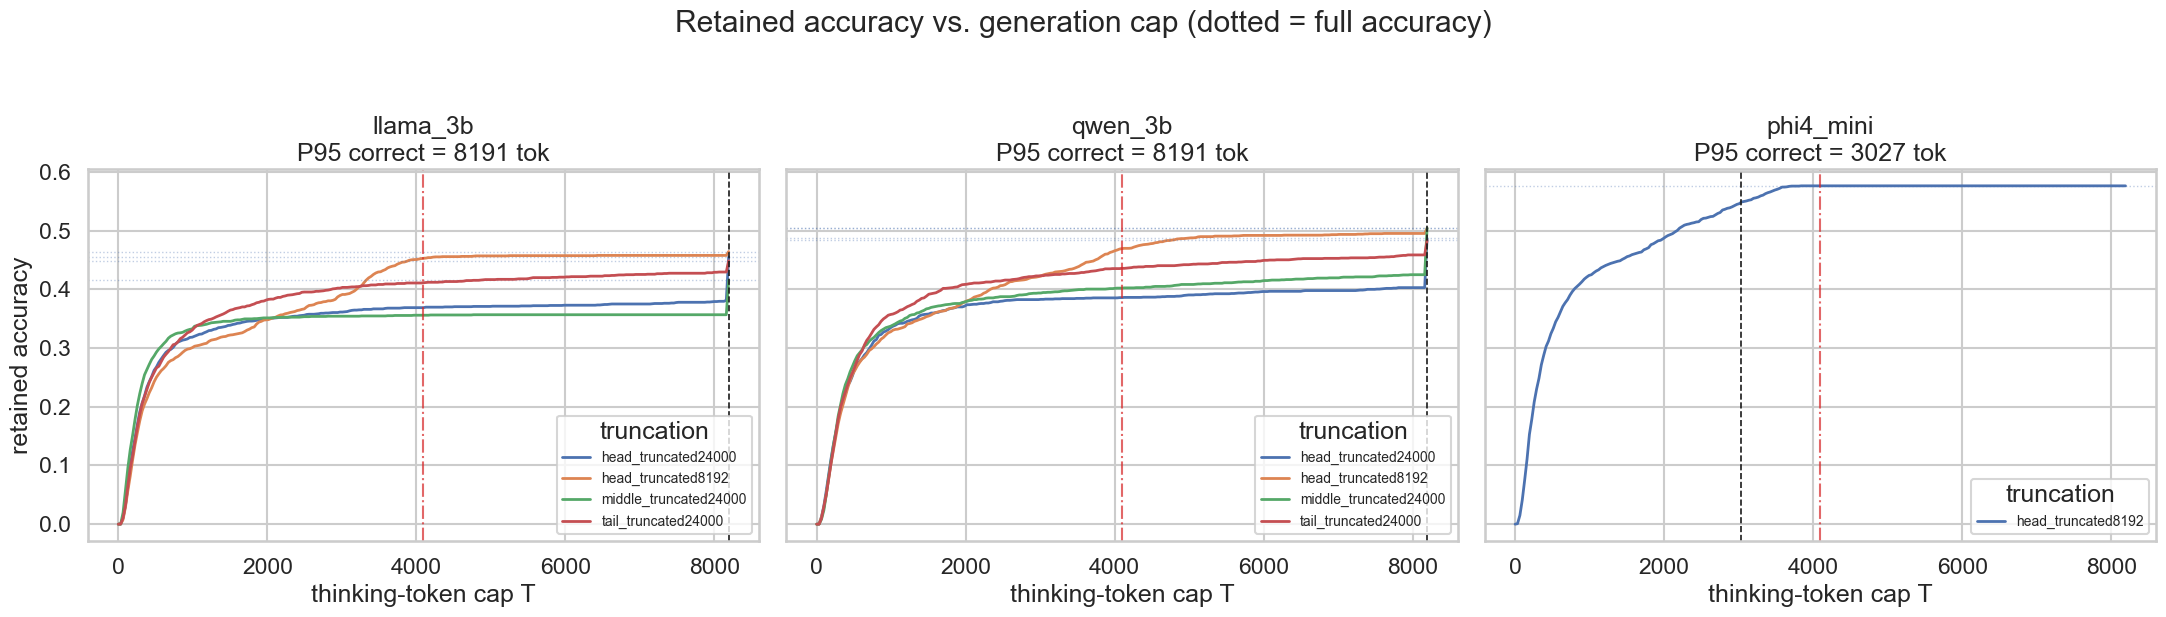

In [ ]:
def retained_curve(sub, grid):
    total = len(sub)
    correct_tok = np.sort(sub.loc[sub.is_correct, "reason_tokens"].to_numpy())
    return np.searchsorted(correct_tok, grid, side="right") / total


grid = np.arange(0, THINKING_BUDGET + 1, 32)

fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=True)
for ax, model in zip(axes, MODEL_ORDER):
    md_ = final_df[final_df.model == model]
    for variant, sub in md_.groupby("variant", observed=True):
        ax.plot(grid, retained_curve(sub, grid), lw=2, label=variant.replace(f"{model}_", ""))
        ax.axhline(sub.is_correct.mean(), ls=":", lw=1, alpha=0.35)
    p95 = md_.loc[md_.is_correct, "reason_tokens"].quantile(0.95)
    ax.axvline(p95, color="k", ls="--", lw=1.2)
    ax.axvline(CAP_FOCUS, color="tab:red", ls="-.", lw=1.5, alpha=0.7)  # cap @ 4096
    ax.set_title(f"{model}\nP95 correct = {int(p95)} tok")
    ax.set_xlabel("thinking-token cap T")
    ax.legend(fontsize=10, title="truncation")
axes[0].set_ylabel("retained accuracy")
fig.suptitle("Retained accuracy vs. generation cap (dotted = full accuracy)", y=1.04)
fig.tight_layout()
fig.savefig(OUT_DIR / "retained_accuracy_tokens.png", dpi=120, bbox_inches="tight")
plt.show()

**Normalized view** — fraction of the model's *own* accuracy retained, vs cap (tokens and chars).

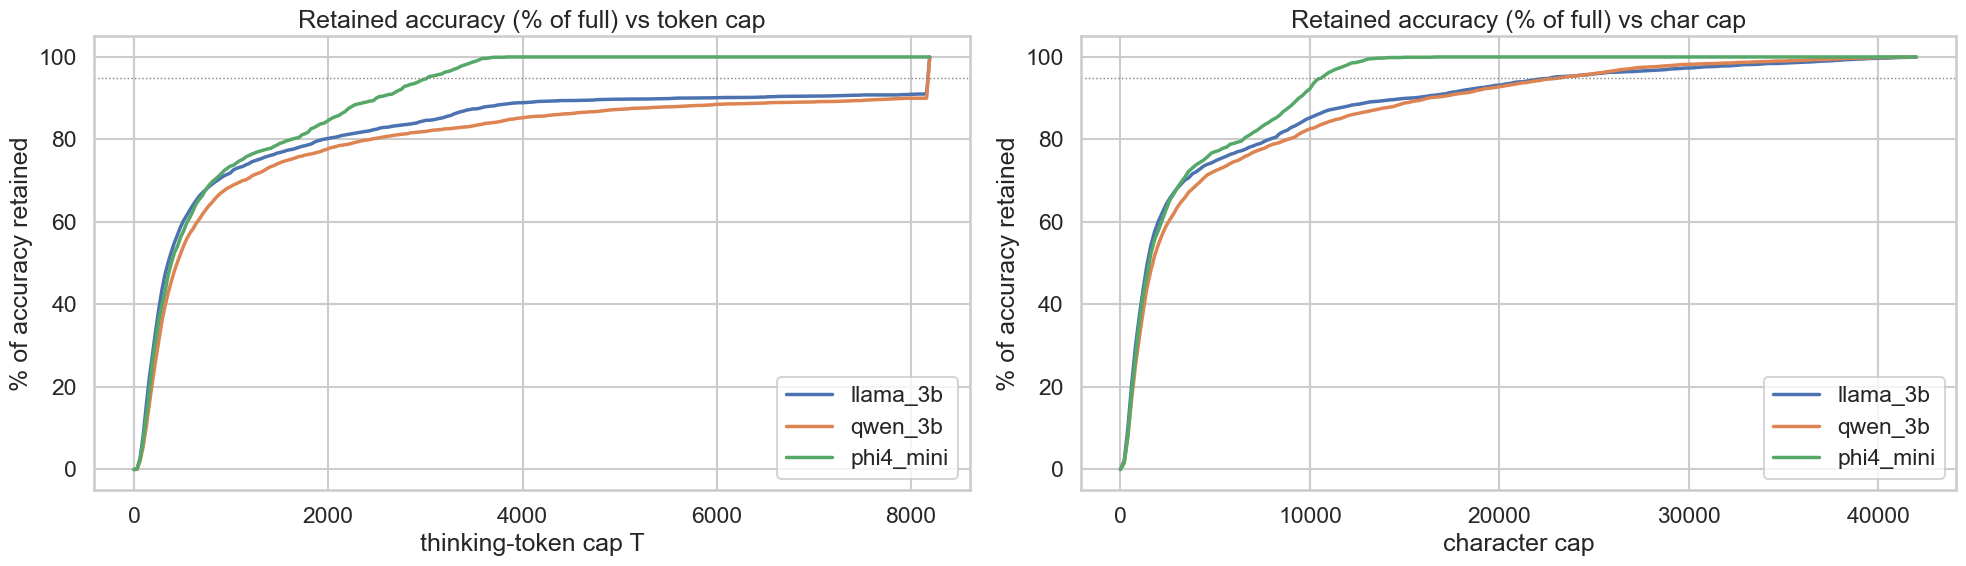

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
# tokens
for model in MODEL_ORDER:
    md_ = final_df[final_df.model == model]
    acc = md_.is_correct.mean()
    y = retained_curve(md_, grid) / acc
    axes[0].plot(grid, 100 * y, lw=2.5, label=model)
axes[0].axhline(95, color="grey", ls=":", lw=1)
axes[0].set(
    xlabel="thinking-token cap T", ylabel="% of accuracy retained", title="Retained accuracy (% of full) vs token cap"
)
axes[0].legend()
# chars
cgrid = np.arange(0, int(final_df.reason_chars.quantile(0.999)), 200)
for model in MODEL_ORDER:
    md_ = final_df[final_df.model == model]
    total, acc = len(md_), md_.is_correct.mean()
    ctok = np.sort(md_.loc[md_.is_correct, "reason_chars"].to_numpy())
    y = (np.searchsorted(ctok, cgrid, side="right") / total) / acc
    axes[1].plot(cgrid, 100 * y, lw=2.5, label=model)
axes[1].axhline(95, color="grey", ls=":", lw=1)
axes[1].set(xlabel="character cap", ylabel="% of accuracy retained", title="Retained accuracy (% of full) vs char cap")
axes[1].legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "retained_accuracy_normalized.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Length distributions: correct vs. incorrect

The ECDF and violin plots visualise the core question: are correct chains short and long
chains garbage? (Note the spike at the 8192 ceiling = budget-exhausted chains.)

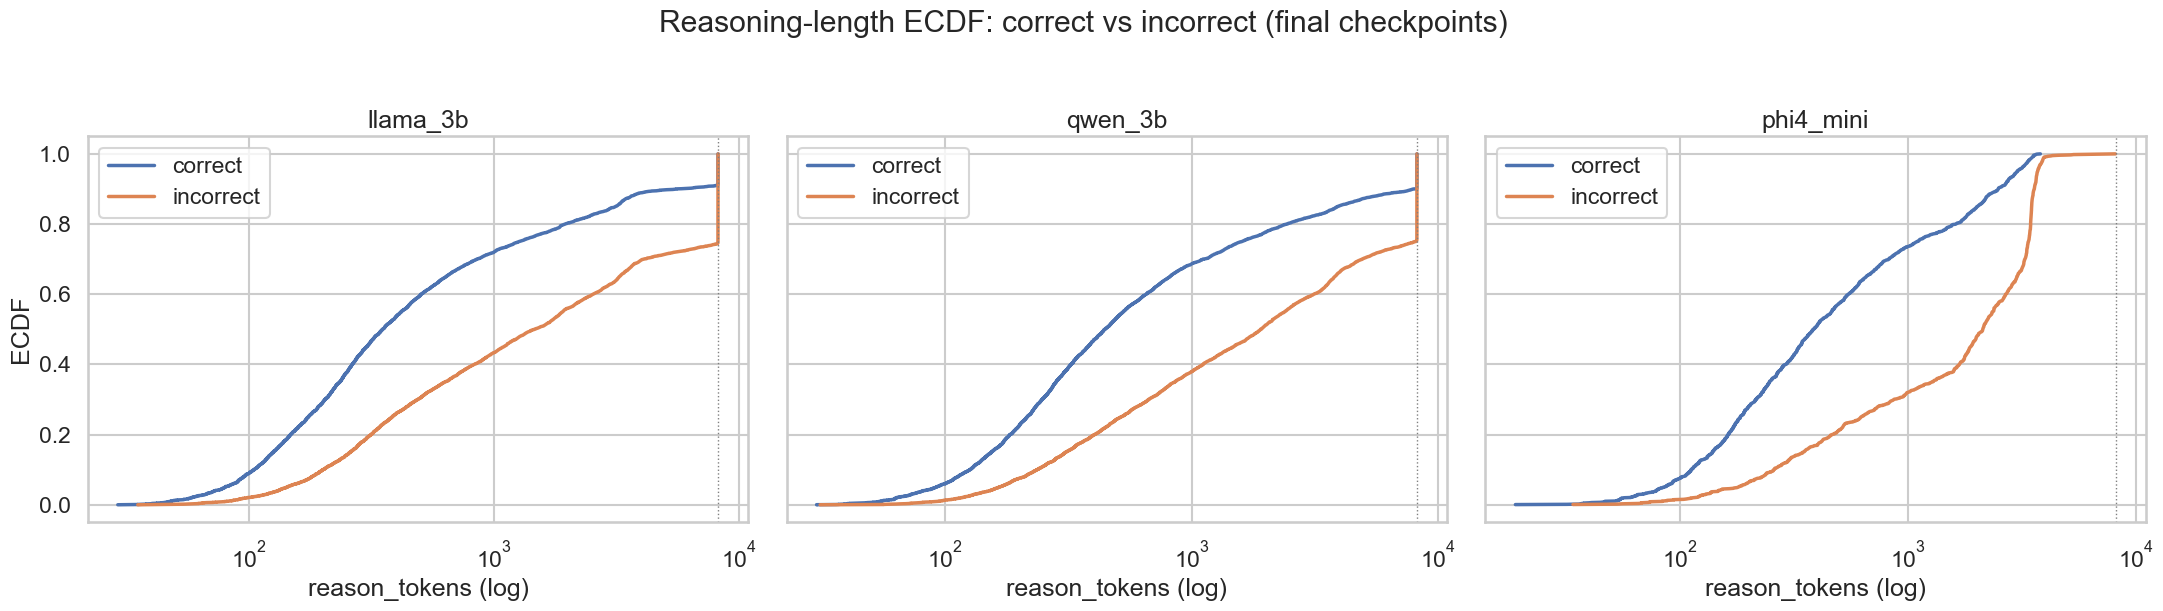

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=True)
for ax, model in zip(axes, MODEL_ORDER):
    md_ = final_df[final_df.model == model]
    for corr, lab in [(True, "correct"), (False, "incorrect")]:
        v = np.sort(md_.loc[md_.is_correct == corr, "reason_tokens"].to_numpy())
        if len(v):
            ax.plot(v, np.arange(1, len(v) + 1) / len(v), lw=2.5, label=lab)
    ax.axvline(THINKING_BUDGET, color="grey", ls=":", lw=1)
    ax.set_xscale("log")
    ax.set_title(model)
    ax.set_xlabel("reason_tokens (log)")
    ax.legend()
axes[0].set_ylabel("ECDF")
fig.suptitle("Reasoning-length ECDF: correct vs incorrect (final checkpoints)", y=1.03)
fig.tight_layout()
fig.savefig(OUT_DIR / "ecdf_correct_vs_incorrect.png", dpi=120, bbox_inches="tight")
plt.show()

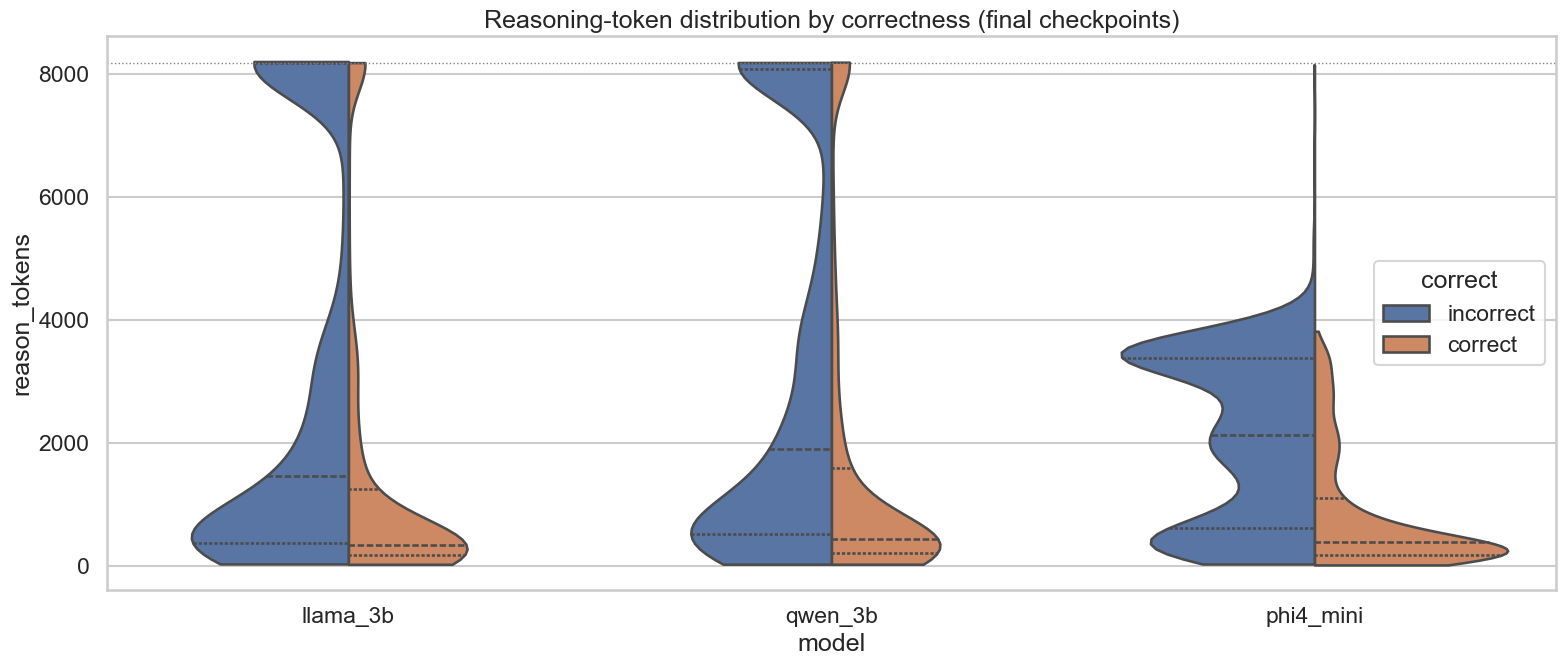

In [ ]:
fig, ax = plt.subplots(figsize=(16, 7))
plot_df = final_df.assign(correct=np.where(final_df.is_correct, "correct", "incorrect"))
sns.violinplot(
    data=plot_df,
    x="model",
    y="reason_tokens",
    hue="correct",
    order=MODEL_ORDER,
    split=True,
    cut=0,
    inner="quartile",
    ax=ax,
)
ax.axhline(THINKING_BUDGET, color="grey", ls=":", lw=1)
ax.set_title("Reasoning-token distribution by correctness (final checkpoints)")
ax.set_ylabel("reason_tokens")
fig.tight_layout()
fig.savefig(OUT_DIR / "violin_tokens_by_correctness.png", dpi=120, bbox_inches="tight")
plt.show()

## 9. Length dynamics across epochs

How does correct-chain length evolve during training, and does the budget-exhaustion rate
change? Uses **all** checkpoints. For the two `llama_3b …24000` variants whose summaries
lack epoch labels, epoch is inferred as `round(step / min_step)` — validated to match the
known labels exactly.

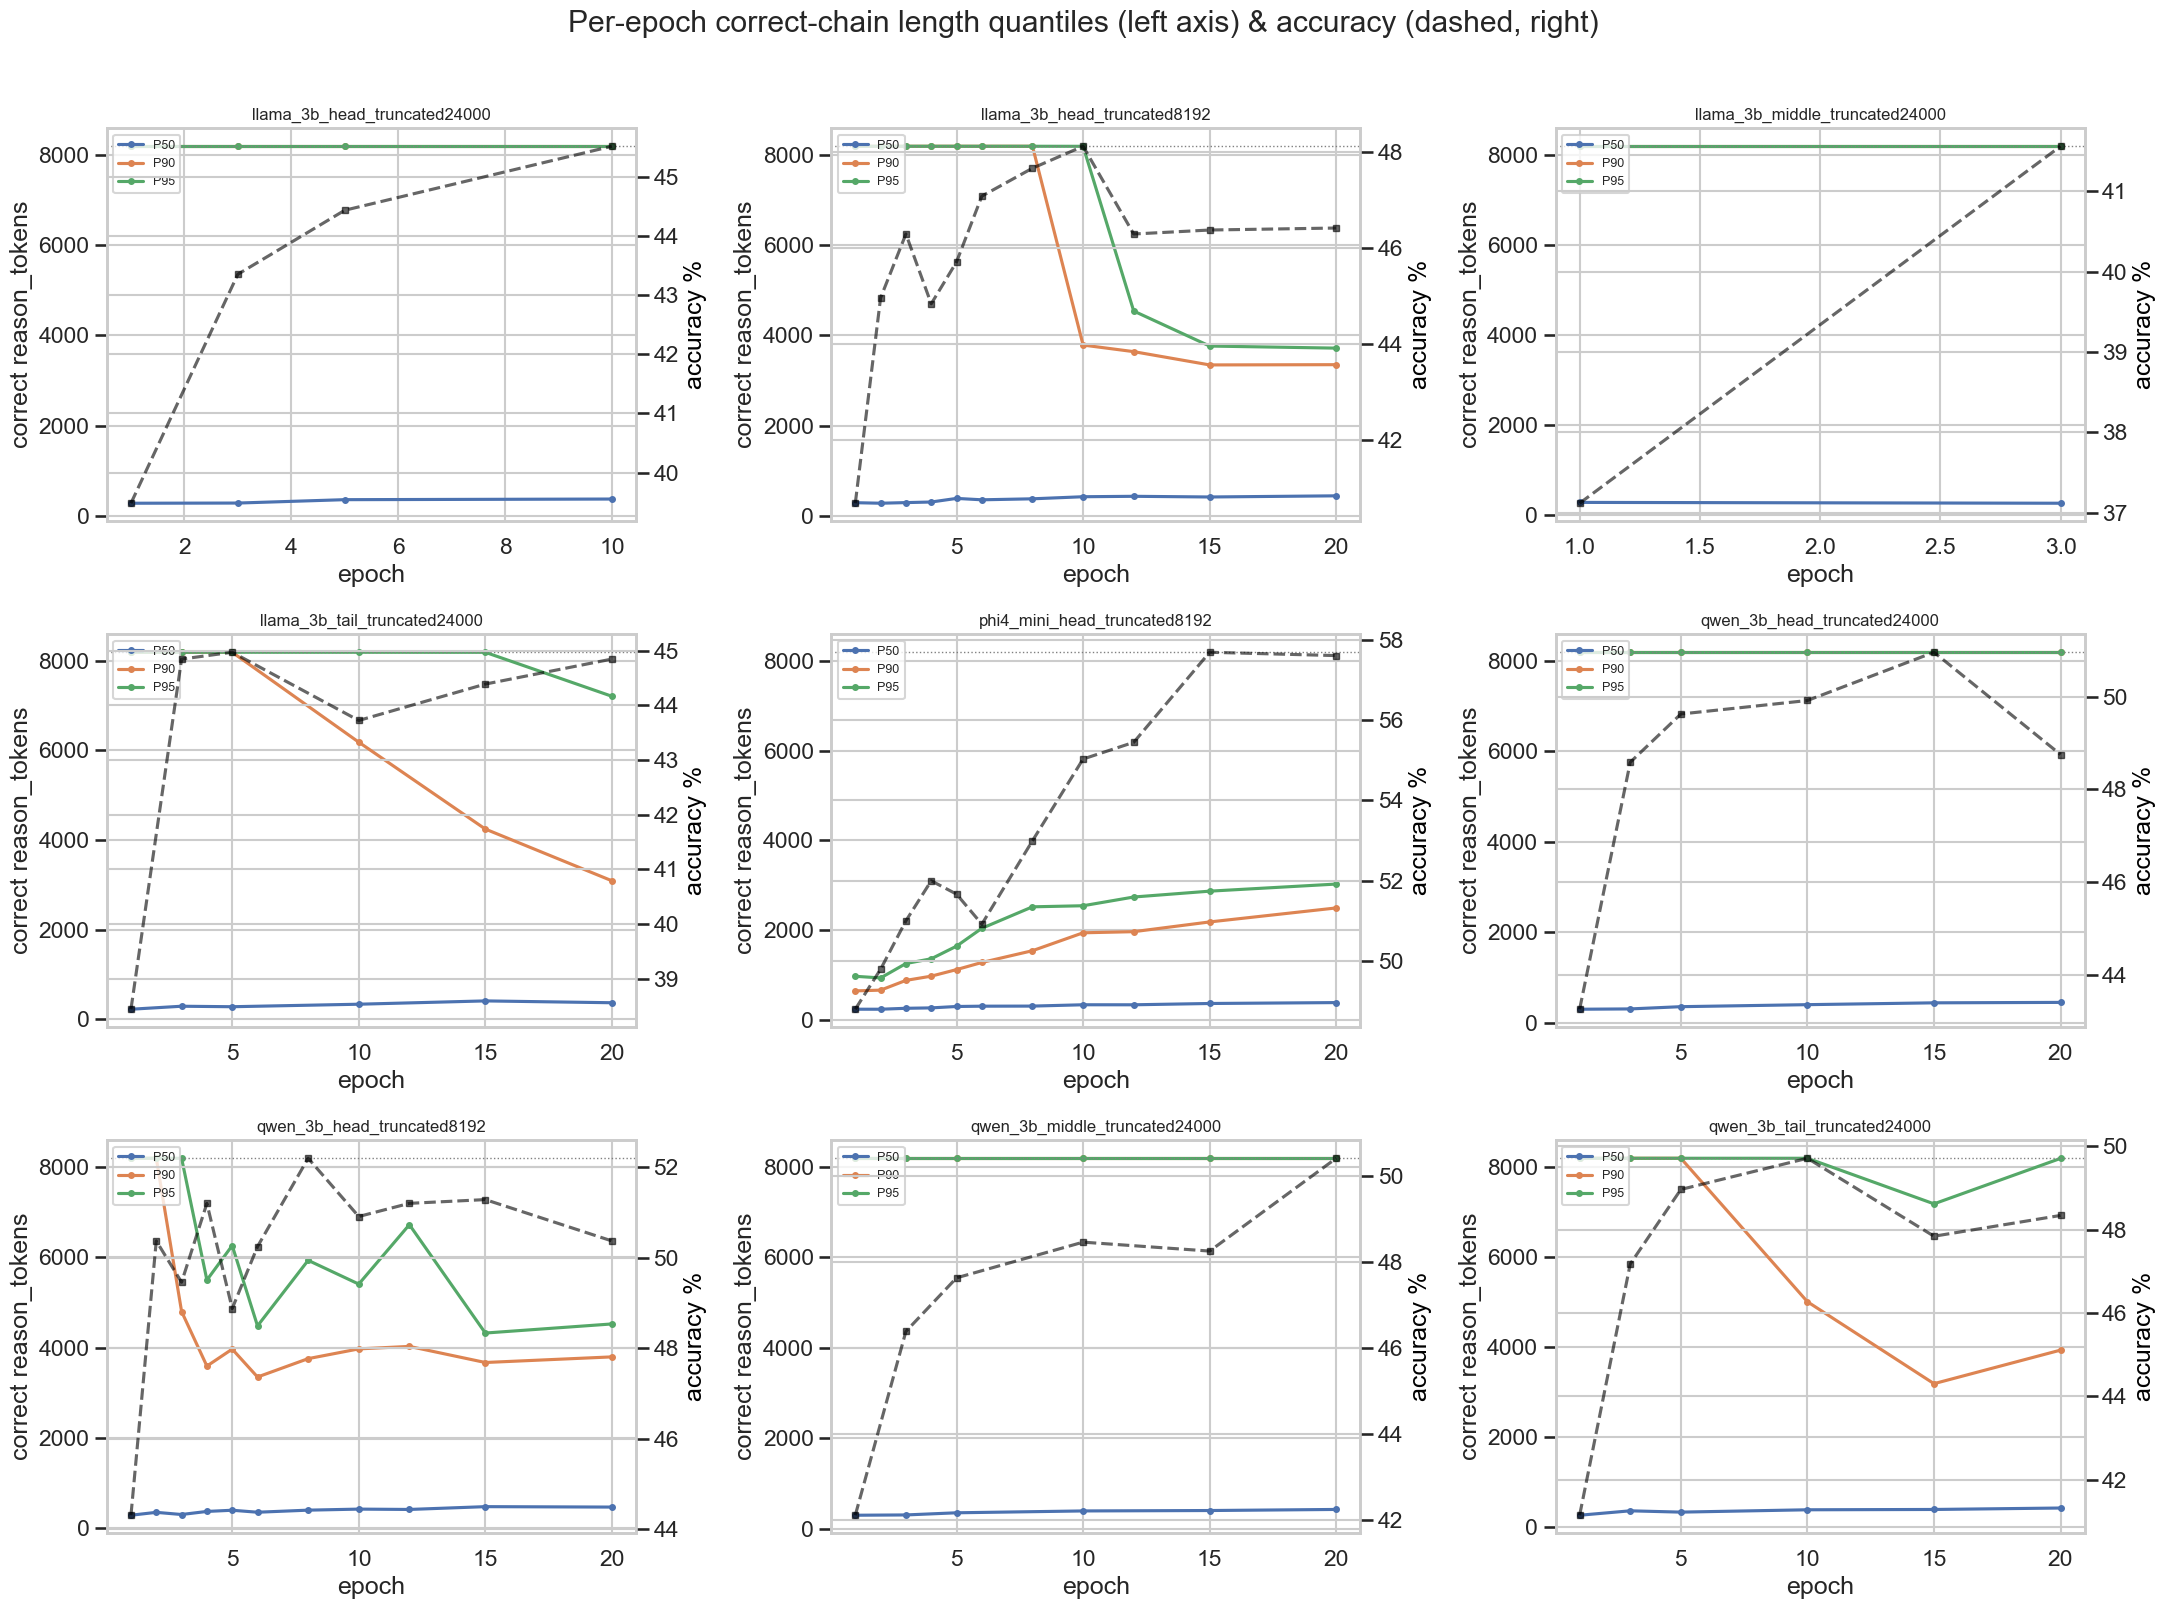

In [ ]:
df["epoch_filled"] = df["epoch"]
est = (df["ckpt_step"] / df.groupby("variant")["ckpt_step"].transform("min")).round()
df["epoch_filled"] = df["epoch_filled"].fillna(est)


def correct_q(sub, q):
    c = sub.loc[sub.is_correct, "reason_tokens"]
    return c.quantile(q) if len(c) else np.nan


dyn = (
    df.groupby(["model", "variant", "epoch_filled"], observed=True)
    .apply(
        lambda s: pd.Series(
            {
                "accuracy": s.is_correct.mean(),
                "correct_p50": correct_q(s, 0.5),
                "correct_p90": correct_q(s, 0.9),
                "correct_p95": correct_q(s, 0.95),
                "frac_budget_exhausted": s.is_thinking_budget_exhausted.mean(),
            }
        ),
        include_groups=False,
    )
    .reset_index()
    .sort_values(["variant", "epoch_filled"])
)

variants = sel.variant.tolist()
fig, axes = plt.subplots(3, 3, figsize=(22, 16))
for ax, variant in zip(axes.ravel(), variants):
    d = dyn[dyn.variant == variant]
    ax.plot(d.epoch_filled, d.correct_p50, "-o", ms=4, label="P50")
    ax.plot(d.epoch_filled, d.correct_p90, "-o", ms=4, label="P90")
    ax.plot(d.epoch_filled, d.correct_p95, "-o", ms=4, label="P95")
    ax.axhline(THINKING_BUDGET, color="grey", ls=":", lw=1)
    ax.set_title(variant, fontsize=12)
    ax.set_xlabel("epoch")
    ax.set_ylabel("correct reason_tokens")
    ax2 = ax.twinx()
    ax2.plot(d.epoch_filled, 100 * d.accuracy, "--s", color="black", ms=4, alpha=0.6)
    ax2.set_ylabel("accuracy %", color="black")
    ax.legend(fontsize=9, loc="upper left")
for ax in axes.ravel()[len(variants) :]:
    ax.axis("off")
fig.suptitle("Per-epoch correct-chain length quantiles (left axis) & accuracy (dashed, right)", y=1.01)
fig.tight_layout()
fig.savefig(OUT_DIR / "epoch_length_dynamics.png", dpi=110, bbox_inches="tight")
plt.show()

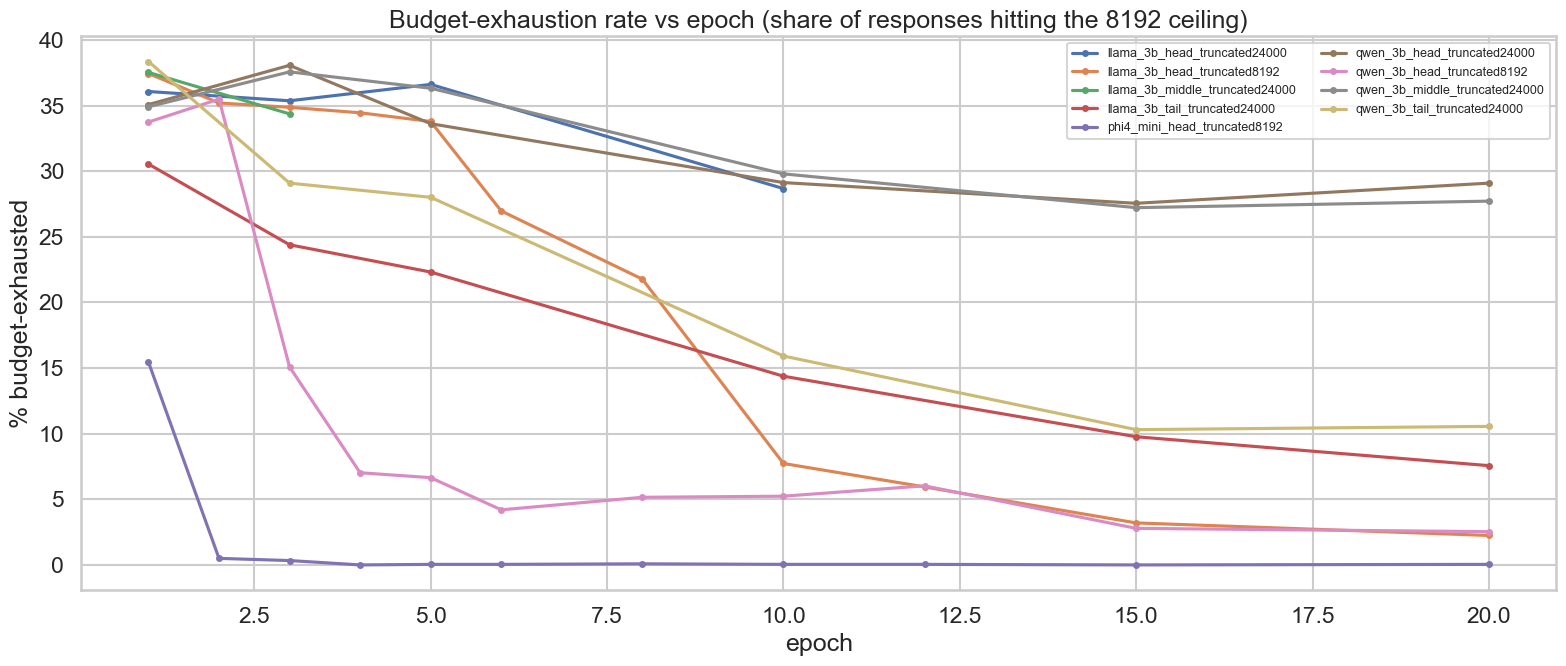

In [ ]:
fig, ax = plt.subplots(figsize=(16, 7))
for variant, d in dyn.groupby("variant"):
    ax.plot(d.epoch_filled, 100 * d.frac_budget_exhausted, "-o", ms=4, label=variant)
ax.set(
    xlabel="epoch",
    ylabel="% budget-exhausted",
    title="Budget-exhaustion rate vs epoch (share of responses hitting the 8192 ceiling)",
)
ax.legend(fontsize=9, ncol=2)
fig.tight_layout()
fig.savefig(OUT_DIR / "epoch_budget_exhaustion.png", dpi=120, bbox_inches="tight")
plt.show()

## 10. Recommendation: speedup vs. retained accuracy

For each cap `T`, the **speedup proxy** = `mean(reason_tokens) / mean(min(reason_tokens, T))`
(eval wall-time ≈ ∝ thinking tokens generated, greedy + batched; ignores prompt prefill and
the few answer tokens). **retain%** = fraction of the model's accuracy kept at that cap.
`%correct_budget_exhausted` shows how much of the accuracy lives at the 8192 ceiling — high
values mean early stopping carries a real accuracy cost. Computed on **final** checkpoints.

In [ ]:
T_GRID = [256, 512, 768, 1024, 1536, 2048, 3072, 4096, 6144]


def speedup_row(sub, label):
    mean_now = sub.reason_tokens.mean()
    acc = sub.is_correct.mean()
    corr = sub.loc[sub.is_correct]
    out = {
        "group": label,
        "n": len(sub),
        "accuracy_%": round(100 * acc, 1),
        "mean_tok_now": round(mean_now, 0),
        "correct_BE_%": round(100 * corr.is_thinking_budget_exhausted.mean(), 1),
        "P95_corr_tok": int(corr.reason_tokens.quantile(0.95)),
        "P99_corr_tok": int(corr.reason_tokens.quantile(0.99)),
    }
    for T in T_GRID:
        capped = np.minimum(sub.reason_tokens, T).mean()
        ret = ((sub.is_correct) & (sub.reason_tokens <= T)).mean() / acc
        out[f"x@{T}"] = round(mean_now / capped, 2)
        out[f"keep%@{T}"] = round(100 * ret, 1)
    return out


rec = pd.DataFrame(
    [speedup_row(final_df, "ALL")] + [speedup_row(final_df[final_df.model == m], m) for m in MODEL_ORDER]
)
rec.to_csv(OUT_DIR / "recommendation.csv", index=False)

# full retain/speedup curve per variant (backing data for the plots above)
curve_rows = []
for variant, sub in final_df.groupby("variant", observed=True):
    acc = sub.is_correct.mean()
    mean_v = sub.reason_tokens.mean()
    for T in range(0, THINKING_BUDGET + 1, 64):
        capped = np.minimum(sub.reason_tokens, T).mean()
        ret_acc = ((sub.is_correct) & (sub.reason_tokens <= T)).mean()
        curve_rows.append(
            {
                "variant": variant,
                "T_tokens": T,
                "retained_accuracy": ret_acc,
                "retained_frac": ret_acc / acc if acc else np.nan,
                "speedup_proxy": mean_v / capped if capped else np.nan,
            }
        )
pd.DataFrame(curve_rows).to_csv(OUT_DIR / "retain_speedup_curve.csv", index=False)
print("saved recommendation.csv and retain_speedup_curve.csv")
rec.set_index("group")

saved recommendation.csv and retain_speedup_curve.csv


,n,accuracy_%,mean_tok_now,correct_BE_%,P95_corr_tok,P99_corr_tok,x@256,keep%@256,x@512,keep%@512,x@768,keep%@768,x@1024,keep%@1024,x@1536,keep%@1536,x@2048,keep%@2048,x@3072,keep%@3072,x@4096,keep%@4096,x@6144,keep%@6144
group,,,,,,,,,,,,,,,,,,,,,,,,
ALL,21654,48.2,2320.0,8.3,8191,8191,9.97,35.0,5.78,57.3,4.31,66.4,3.52,71.1,2.66,76.3,2.20,80.0,1.70,85.0,1.45,88.9,1.17,90.8
llama_3b,9624,44.6,2379.0,9.0,8191,8191,10.33,38.9,6.06,60.4,4.53,68.5,3.71,72.6,2.81,77.0,2.32,80.5,1.79,84.7,1.51,89.0,1.19,90.2
qwen_3b,9624,49.5,2504.0,10.0,8191,8191,10.63,31.2,6.10,54.3,4.52,63.9,3.69,69.0,2.79,74.6,2.29,78.1,1.77,82.2,1.48,85.5,1.18,88.6
phi4_mini,2406,57.6,1351.0,0.0,3027,3520,5.86,36.1,3.40,57.9,2.54,68.8,2.08,73.7,1.57,79.3,1.30,85.3,1.06,95.4,1.00,100.0,1.00,100.0


### Focused analysis — cap @ 4096 thinking tokens, per variant

`4096` is half the budget. This breaks the trade-off down to the variant level: the speedup
proxy, the accuracy retained, and the share of currently-correct answers that would be lost
(those whose reasoning exceeds 4096 tokens). Sorted worst-to-best by accuracy kept.

In [ ]:
def cap_analysis(d, T):
    rows = []
    for variant, sub in d.groupby("variant", observed=True):
        acc = sub.is_correct.mean()
        mean_now = sub.reason_tokens.mean()
        capped = np.minimum(sub.reason_tokens, T).mean()
        n_corr = int(sub.is_correct.sum())
        ret_acc = ((sub.is_correct) & (sub.reason_tokens <= T)).mean()
        lost = int(((sub.is_correct) & (sub.reason_tokens > T)).sum())
        rows.append(
            {
                "variant": variant,
                "accuracy_%": round(100 * acc, 1),
                "mean_tok_now": round(mean_now, 0),
                "mean_tok_capped": round(capped, 0),
                f"speedup@{T}": round(mean_now / capped, 2),
                f"retained_acc_%@{T}": round(100 * ret_acc, 1),
                f"keep%_of_acc@{T}": round(100 * ret_acc / acc, 1),
                "correct_lost": lost,
                "correct_lost_%": round(100 * lost / max(n_corr, 1), 1),
            }
        )
    return pd.DataFrame(rows).sort_values(f"keep%_of_acc@{T}").reset_index(drop=True)


cap_tbl = cap_analysis(final_df, CAP_FOCUS)
cap_tbl.to_csv(OUT_DIR / f"cap_analysis_T{CAP_FOCUS}.csv", index=False)
print(f"cap @ {CAP_FOCUS} tokens — per variant (final checkpoints)")
cap_tbl

cap @ 4096 tokens — per variant (final checkpoints)


,variant,accuracy_%,mean_tok_now,mean_tok_capped,speedup@4096,retained_acc_%@4096,keep%_of_acc@4096,correct_lost,correct_lost_%
0,qwen_3b_head_truncated24000,48.8,3125.0,1845.0,1.69,38.6,79.1,245,20.9
1,qwen_3b_middle_truncated24000,50.4,3103.0,1862.0,1.67,40.2,79.7,246,20.3
2,llama_3b_head_truncated24000,45.5,3003.0,1753.0,1.71,36.9,81.0,208,19.0
3,llama_3b_middle_truncated24000,41.6,3107.0,1697.0,1.83,35.6,85.6,144,14.4
4,qwen_3b_tail_truncated24000,48.3,2009.0,1440.0,1.40,43.6,90.1,115,9.9
5,llama_3b_tail_truncated24000,44.8,1816.0,1363.0,1.33,41.1,91.7,90,8.3
6,qwen_3b_head_truncated8192,50.4,1780.0,1613.0,1.10,46.9,93.2,83,6.8
7,llama_3b_head_truncated8192,46.4,1589.0,1489.0,1.07,45.3,97.5,28,2.5
8,phi4_mini_head_truncated8192,57.6,1351.0,1347.0,1.00,57.6,100.0,0,0.0


### Headline read-out

In [ ]:
def at(group, T):
    r = rec.set_index("group").loc[group]
    return f"{r[f'x@{T}']:.2f}× faster, keeps {r[f'keep%@{T}']:.0f}% of accuracy"


for g in ["ALL"] + MODEL_ORDER:
    r = rec.set_index("group").loc[g]
    print(
        f"{g:10s} acc={r['accuracy_%']:.1f}%  "
        f"{r['correct_BE_%']:.0f}% of correct hit the ceiling | "
        f"cap@1024: {at(g, 1024)} | cap@2048: {at(g, 2048)} | cap@4096: {at(g, 4096)}"
    )

ALL        acc=48.2%  8% of correct hit the ceiling | cap@1024: 3.52× faster, keeps 71% of accuracy | cap@2048: 2.20× faster, keeps 80% of accuracy | cap@4096: 1.45× faster, keeps 89% of accuracy
llama_3b   acc=44.6%  9% of correct hit the ceiling | cap@1024: 3.71× faster, keeps 73% of accuracy | cap@2048: 2.32× faster, keeps 80% of accuracy | cap@4096: 1.51× faster, keeps 89% of accuracy
qwen_3b    acc=49.5%  10% of correct hit the ceiling | cap@1024: 3.69× faster, keeps 69% of accuracy | cap@2048: 2.29× faster, keeps 78% of accuracy | cap@4096: 1.48× faster, keeps 86% of accuracy
phi4_mini  acc=57.6%  0% of correct hit the ceiling | cap@1024: 2.08× faster, keeps 74% of accuracy | cap@2048: 1.30× faster, keeps 85% of accuracy | cap@4096: 1.00× faster, keeps 100% of accuracy


## Findings

- **The median correct chain is tiny** — ~340–440 tokens (~4–6% of the 8192 budget), vs
  ~1900+ for incorrect. Most correct answers really do come from short reasoning.
- **But the tail is not pure garbage.** For `llama_3b`/`qwen_3b` a substantial share of
  *correct* answers (often 20–40%) are **budget-exhausted** (chains pinned at the 8192
  ceiling), so the correct-length distribution is **bimodal**. Capping early is therefore a
  real **speed/accuracy trade**, quantified by the retained-accuracy curve — not free.
  Examples (final, all variants pooled): **cap@1024 ≈ 3.5× faster, keeps ~71%** of accuracy;
  **cap@2048 ≈ 2.2× faster, keeps ~80%**.
- **Truncation value dominates length.** Models trained on `truncated8192` data ramble far
  less than `truncated24000` (e.g. llama head-8192 correct P90 ≈ 3.4k tok & ~1% exhausted,
  vs head-24000 P90 = 8191 & ~16% exhausted). The 8192-trained models can be evaluated with
  a much smaller cap at little cost.
- **`phi4_mini` is already efficient** — correct chains cap out around P99 ≈ 3.5k tokens and
  essentially never hit the budget; its eval can be capped at ~3.8k tokens losing ~nothing.
- **Practical guidance.** Pick the cap per `(model, truncation_value)` from the retained
  curve / recommendation table for the accuracy loss you can tolerate; `truncated8192` and
  `phi4_mini` runs are the easiest wins. Budget-exhausted-correct answers (forced after the
  ceiling) are the least reliable, so the true accuracy cost of early stopping is likely
  smaller than the upper bound shown here.

All tables (CSV) and figures (PNG) are written to `artifacts/reasoning_length_vs_accuracy/`.